In [1]:
from secrets import randbelow

In [2]:
# class F_q:
#     def __init__(x, q):
#         self = x % q

Start by defining the `Point` class. 

In [3]:
class Point:
    """A class of points in F_q x F_q.
    
    Takes as input 
    - components x and y
    - parameters q and d
    
    Specifies defaults for the paramters that apply
    in the case of Ed25519; and defaults for the components 
    that yield the generator for Ed25519. 

    Defines an attribute .doubles_seq that
    is not calculated when an instance is created.

    It is calculated only when the repeated addtion 
    method is first used. It is then saved so  doesn't 
    need to be calculated again. 

    The timing is important because the .doubles() method
    that calculates the list .doubles_seq has to create 255 
    additional curve points and it is important to avoid a
    situation where each time you create one curve point, 
    you create 255 additional curve points.

    Uncomment the print statement in self.doubles() to see a 
    notification each time .doubles.seq is calculated.

    The upper bound for the integers used to specify repeated 
    addition of a point is 2 raised to the power 512.
    In the application to Ed25519, this should be large enough 
    to handle calculation involving repeated addition.

    """
    def __init__(self, x, y, q, d): 
        self.x = x 
        self.y = y 
        self.q = q
        self.a = q-1
        self.d = d
        self.doubles_seq = []


    def __repr__(self):
        nl = "\n" + " " * 4
        if self.q > 2**254:
            return f"{self.__class__.__name__}({nl}{self.x}{nl}{self.y}\n)"
        else:
            s = f"{self.__class__.__name__}"
            s += f"(x={self.x}, y={self.y}, q={self.q}, d={self.d})"
            return s


    def __eq__(self, Other):
        if all(
            [
                isinstance(Other, type(self)),
                self.x == Other.x,
                self.y == Other.y,
                self.q == Other.q,
                self.d == Other.d,
            ]
        ):
            return True
        else:
            return False


    def __add__(self, Other):
        if all([ 
                isinstance(Other, type(self)),
                self.q == Other.q,
                self.d == Other.d,
            ]):
            N = self
            M = Other
            Dx = pow((1 + self.d * M.x * N.x * M.y * N.y), self.q - 2, self.q)
            x = (M.x * N.y + M.y * N.x) * Dx % self.q
            Dy = pow((1 - self.d * M.x * N.x * M.y * N.y), self.q - 2, self.q)
            y = (M.y * N.y + M.x * N.x) * Dy % self.q
            return Point(x=x, y=y, q=self.q, d=self.d)


    def __rmatmul__(self, m):
        br = self.br_from_int(m)
        if len(self.doubles_seq) == 0:
            self.doubles_seq = self.doubles()
        cp = Point(x=0, y=1, q=self.q, d=self.d)
        for b, p in zip(br, self.doubles_seq):
            if b:
                cp += p
        return cp

    
    @classmethod
    def valid_params(cls, q, a, d):
        """
        Confirm whether the parameters q, a and d yield
        an elliptic curve that is complete and not signular.
        """
        # Test whether q is prime only if q < 2**10.
        if q < 2**10:
            if not cls.is_prime(q):
                return False
        # For co-factor to be 8
        if q % 8 != 5:
            return False
        # To avoid singularity, need a != d, both != 0
        if a % q == 0 or d % q == 0 or a % q == d % q:
            return False
        # For completeness, d must be non-square in F_q
        if pow(d % q, (q - 1) // 2, q) != q - 1:
            return False
        # For completeness, a must be square in F_q
        if pow(a % q, (q - 1) // 2, q) == q - 1:
            return False
        return True


    @classmethod
    def is_prime(cls, n: int) -> bool:
        if n < 2:
            return False
        if n < 4:
            return True
        if n % 2 == 0 or n % 3 == 0:
            return False
        i = 5
        while i * i <= n:
            if n % i == 0 or n % (i + 2) == 0:
                return False
            i += 6
        return True


    @classmethod 
    def Ed(cls, M):
        """The equation that defines the twisted Edwards elliptic curve for the 
        parameters M.q and M.d. The parameter that is often denoted as a is set 
        to -1.
        """
        return (-1 * M.x**2 + M.y**2 - 1 - M.d * M.x**2 * M.y**2) % M.q
            
    
    @classmethod
    def curve_points(cls, q, d):
        """For paramters q and d, returns the set of all curve points. Because 
        it could take impossibly long and could exhaust the available RAM, it 
        would be a mistake to run this method for large values of q.
        """
        points = []
        for x in range(q):
            for y in range(q):
                M = Point(x, y, q, d)
                if cls.Ed(M) == 0:
                    points.append(M)
        return points

    
    @staticmethod
    def br_from_int(m: int) -> list:
        """Used to calculate m repeated sums of a point with itself. 
        If m is too large, it will throw an error.
        """
        if m >= 2**512:
            raise TypeError("The integer supplied is too large.") 
        return [int(b) for b in list(bin(m)[2:])[::-1]]


    def doubles(self):
        """Another function that is used to calculate the repeated 
        sum of a point with itself.
        
        It uses repeated doubling to calculate a sequence 
        of terms of the form 2**2**r @ self. 

        You can uncomment the first line to see on the command 
        line when this function runs. It should run only once and
        only the first time that an expression of the form 
        m @ self is calculated.  
        """
        # print("Calculating the sequence of doubled points.")
        ls = []
        ls.append(self)
        for j in range(1, 512):
            ls.append(ls[-1] + ls[-1])
        self.doubles = ls
        return ls

    
    @classmethod
    def find_params(cls):
        """A function that searches for parameters q and d that are 
        valid and with the property that the large subgroup of curve points 
        has a cofator equal to 8.
        """
        
        for q in range(100, 200):
            for nd in range(2, 10):
                d = -nd % q
                a = -1 % q
                if not cls.valid_params(q, a, d):
                    continue
                n = len(cls.curve_points(q, d))
                if n % 8 == 0 and cls.is_prime(n // 8):
                    print(f"q={q}, d={q - nd}, #E={n}, cofactor=8, r={n // 8}")
                    break


Create two factory functions. 

In [4]:
def point(
    x:int = 15112221349535400772501151409588531511454012693041857206046113283949847762202, 
    y:int = 46316835694926478169428394003475163141307993866256225615783033603165251855960
) -> Point:
    q = 2**255 - 19
    d = (-1) * 121665 * pow(121666, q - 2, q) % q
    return Point(x=x, y=y, q=q, d=d)

def point_149(x: int = 4, y: int = 61) -> Point:
    q = 149
    d = 149 - 2
    return Point(x=x, y=y, q=q, d=d)
    

Use them to calculate some points. 

In [5]:
GEN = point() 
IDEN = point(0, 1)

GEN_149 = point_149()
IDEN_149 = point_149(0, 1)

In [6]:
assert IDEN_149 == IDEN_149
assert IDEN_149 != IDEN

## Test `Point.valid_params()`

In [7]:
wp = 2**255 - 19
d = ((-1) * 121665 * pow(121666, wp - 2, wp)) % wp
a = -1 % wp

assert Point.valid_params(wp, a, d)

Confirm that the IDEN points are the additive identity:

In [8]:
assert IDEN + GEN == GEN
assert IDEN_149 + GEN_149 == GEN_149

## Confirm that addition is associative 

The putative addition rule specified by the `Point` class, satisfies the assumptions required for set of curve points $\mathscr{C}$ to be an additive group. In particular, the associative rule holds for curve points:

In [9]:
C = Point.curve_points(q = 149, d = 149 - 2)
ln = len(C)
pt1 = C[randbelow(ln)]
pt2 = C[randbelow(ln)]
pt3 = C[randbelow(ln)]

assert (pt1 + pt2) + pt3 == pt1 + (pt2 + pt3)


It is possible to apply the rule to arbitrary points in $\mathbb{F}_{q} \times \mathbb{F}_{q}\,.$ For points that are not on the curve, the rule is not associative. As a result, $\mathbb{F}_{q} \times \mathbb{F}_{q}$ is not an additive group. 

In [10]:
from secrets import randbelow
q = 149
for j in range(1):
    pt1 = point_149(randbelow(q), randbelow(q))
    pt2 = point_149(randbelow(q), randbelow(q))
    pt3 = point_149(randbelow(q), randbelow(q))

    print("Most randomly selected points are not curve points:")
    print("-" * 50)
    for pt in [pt1, pt2, pt3]:    
        try:
            assert Point.Ed(pt) == 0 
        except AssertionError:
            print(f"Point.Ed({pt}) = {Point.Ed(pt)}")

    print()
    print("The addition rule is not associative on F_q x F_q:") 
    print("-" * 50)
    try:
        assert (pt1 + pt2) + pt3 == pt1 + (pt2 + pt3)
    except AssertionError:
        # print(f"pt1 = {pt1}")
        # print(f"pt2 = {pt2}")
        # print(f"pt3 = {pt3}")
        print(f"(pt1 + pt2) + pt3 = {(pt1 + pt2) + pt3}")
        print(f"pt1 + (pt2 + pt3) = {pt1 + (pt2 + pt3)}")
        print()

Most randomly selected points are not curve points:
--------------------------------------------------
Point.Ed(Point(x=29, y=61, q=149, d=147)) = 25
Point.Ed(Point(x=145, y=17, q=149, d=147)) = 133
Point.Ed(Point(x=30, y=97, q=149, d=147)) = 130

The addition rule is not associative on F_q x F_q:
--------------------------------------------------
(pt1 + pt2) + pt3 = Point(x=124, y=99, q=149, d=147)
pt1 + (pt2 + pt3) = Point(x=77, y=135, q=149, d=147)



## Finding Curve Points 

The components of a Point are elements of $\mathbb{F}_q \times \mathbb{F}_q.$ In math, the components of a point $M$ are denoted by subscripts, with $M_x$ and $M_y$ as its $x$ and $y$ coordinates of the point. In Python, they are available as attributes, `M.x` and `M.y`.  

The class method $\text{Point.}\mathcal{Ed}()$ maps a point to F_q: 

$$\text{Point.}\mathcal{E}_{d}:\mathbb{F}_q \rightarrow \mathbb{F}_{q}\,.$$ 

The value of $$\text{Point.}\mathcal{E}_{d}(M)$$

depends on the components of M and its parameters $M_q$ and $M_d$: 

$$\mathcal{E}_{d}(M) = (- M_x^2 + M_y^2 - 1 - M_d M_x^2  M_y^2)\ \tiny\unicode[Menlo]{x0025}\normalsize\ M_q $$

where $\ \tiny\unicode[Menlo]{x0025}\normalsize $ mimics the Python remainder operation. 

To evaluate the equation on a point M, use the `Point.Ed()` method. 


In [11]:
assert Point.Ed(IDEN) == 0 
assert Point.Ed(GEN) == 0
assert Point.Ed(IDEN_149) == 0 
assert Point.Ed(GEN_149) == 0 

Given parmaters $q$ and $d$, the elliptic curve $\mathscr{C}(q,d)$ is the set of points $M \in \mathbb{F}_{q} \times \mathbb{F}_{q}$ that satisfy the equation $$\mathcal{E}_{d}(M) = 0.$$

## Addition is associative on $\mathscr{C}$

For Ed25519, $\mathscr{C}$ has small subgroups of order $2$, $4$ and $8$ and a large subgroup of order $\ell.$ To understand the structure of such a group, it will help to find a small prime $q$ and a parameter $d$ that yield the same structure. 

The `Point.find_params()` class method identifies values of $100 \le q \lt 200$ and $d$ that will work:


In [12]:
Point.find_params()

q=101, d=99, #E=104, cofactor=8, r=13
q=109, d=107, #E=104, cofactor=8, r=13
q=149, d=147, #E=136, cofactor=8, r=17
q=157, d=155, #E=136, cofactor=8, r=17


Note that for `q = 149`, `d = 147` is the same as `d = -2 % q`. These are the parameters used in the factory function `point_149()`. 

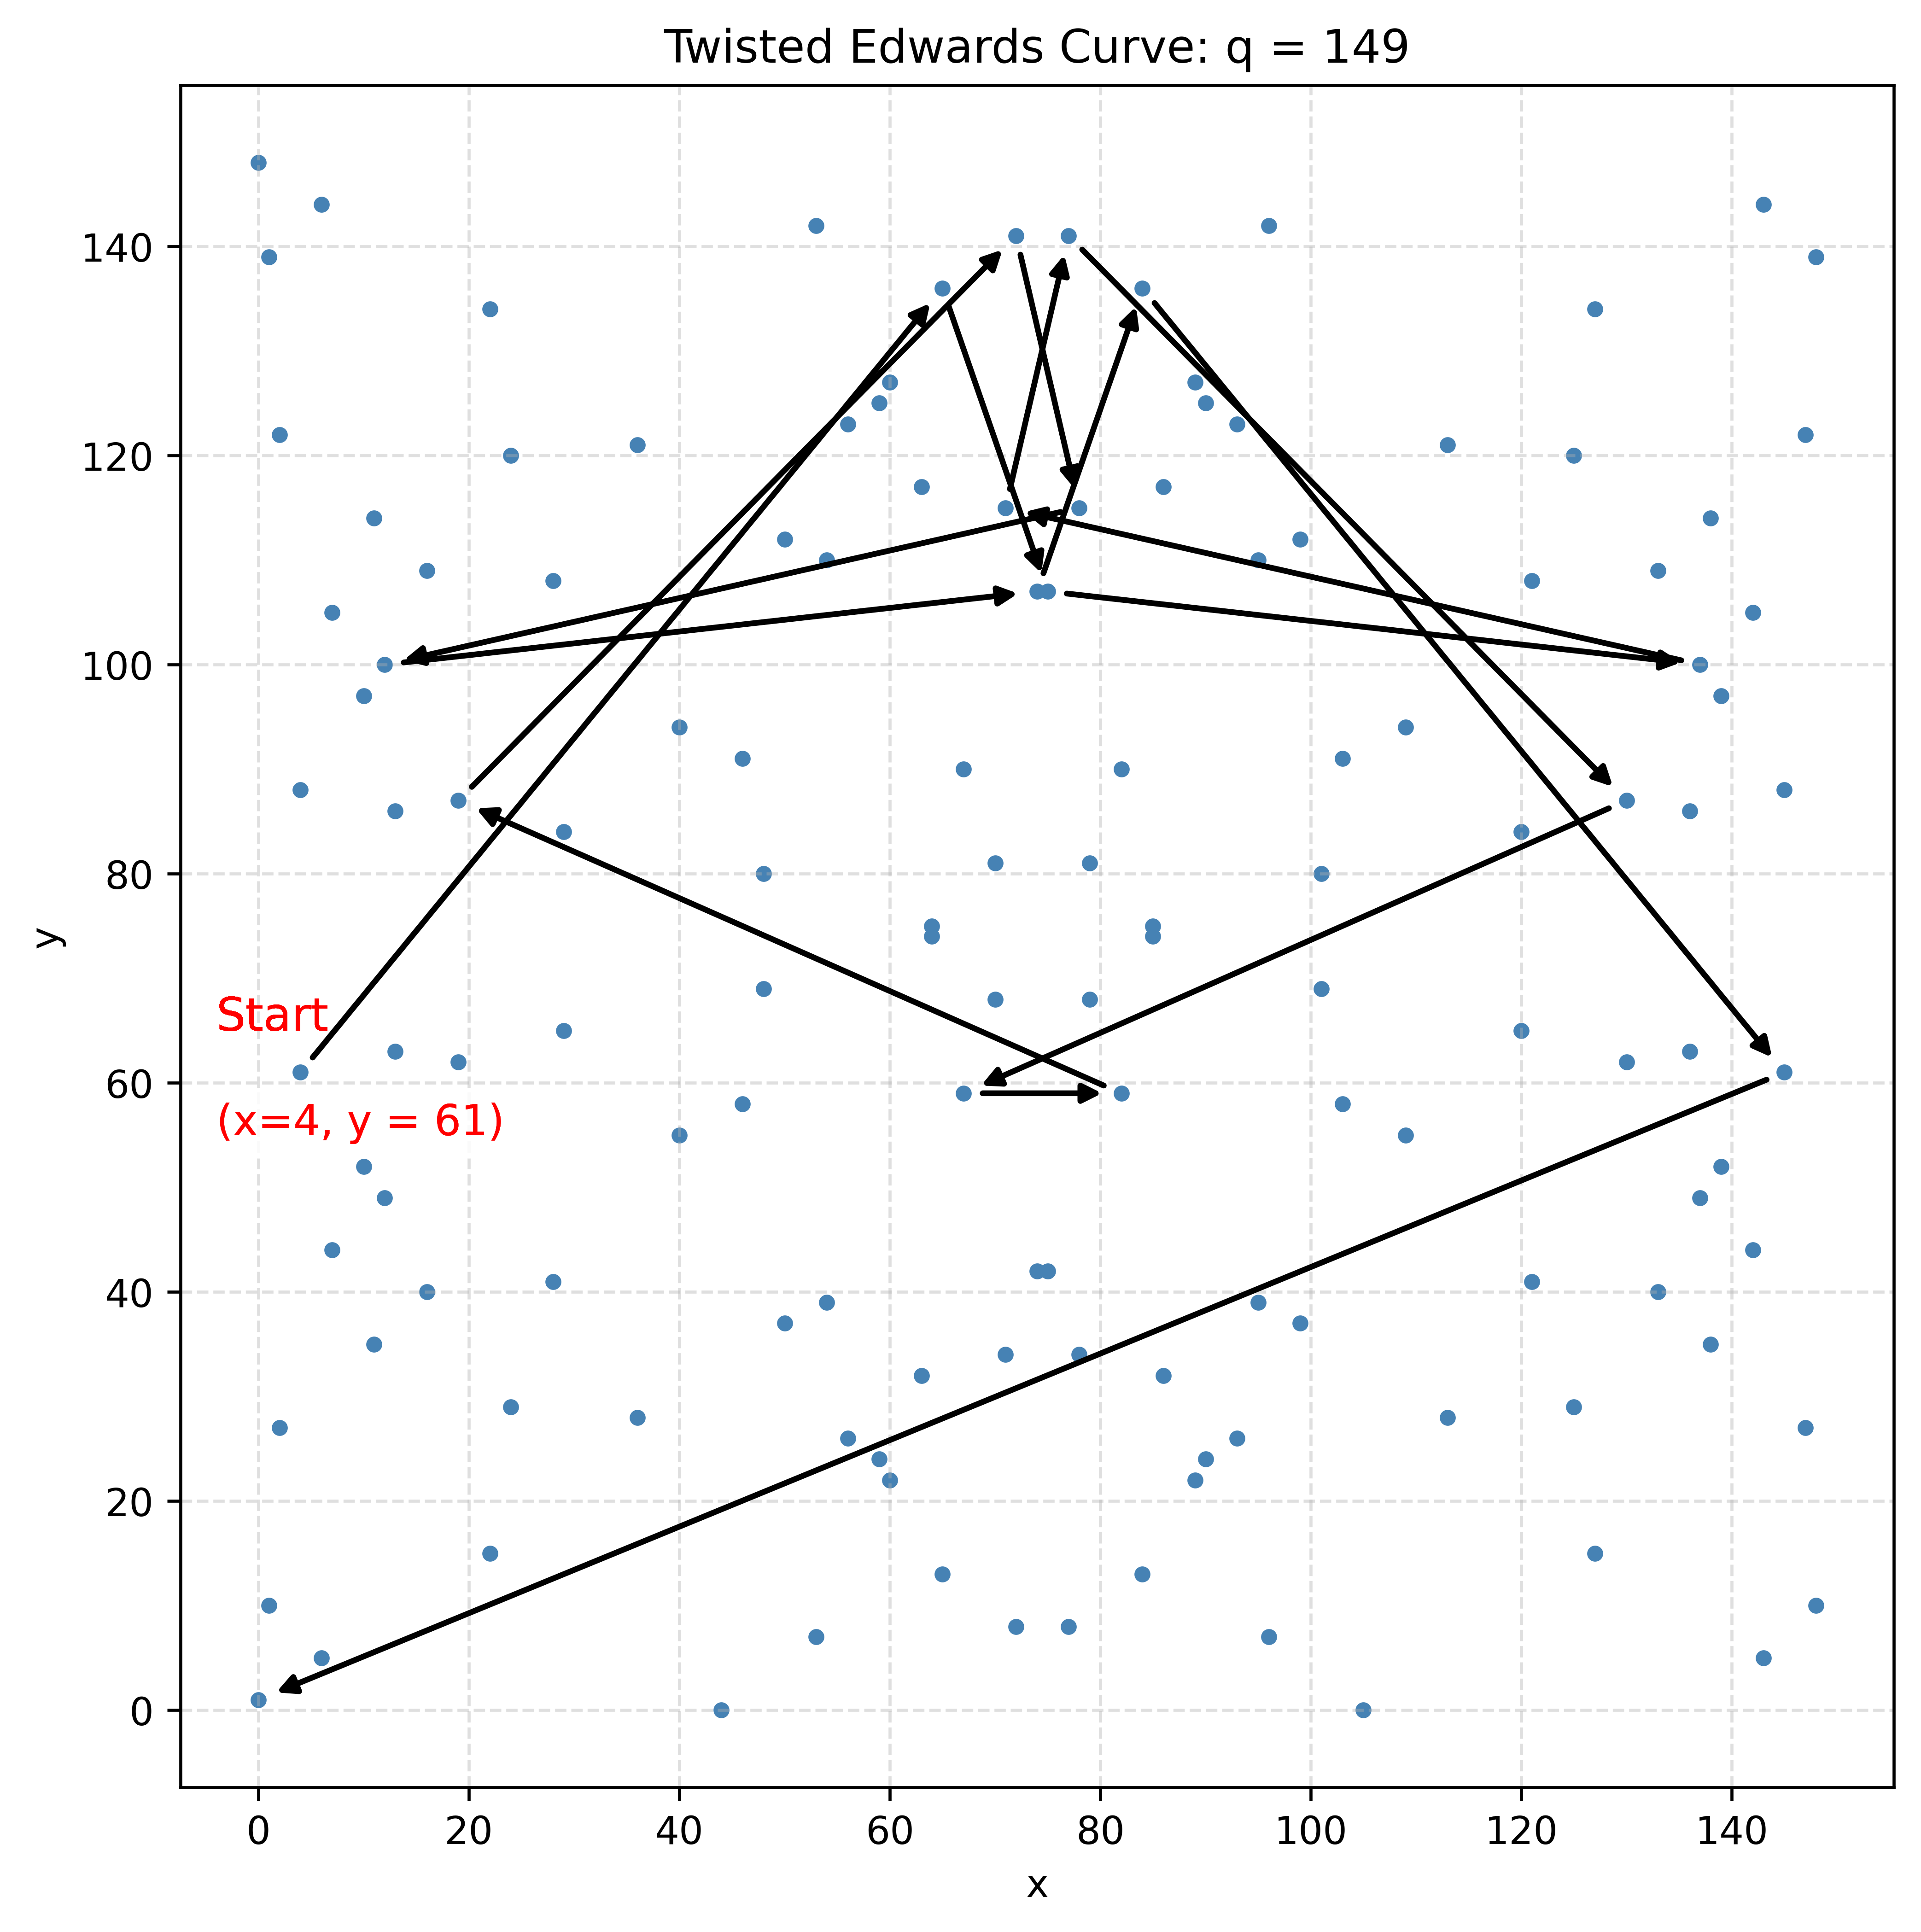

In [15]:
import matplotlib.pyplot as plt

q = 149 
d = 147 

xs_all = []
ys_all = []
for M in Point.curve_points(q = q, d = d):
    xs_all.append(M.x)
    ys_all.append(M.y)

# GEN_149 is a generator for the large subgroup 
GEN_149 = point_149(x=4, y=61)

xs_lsg = []
ys_lsg = []

for j in range(1, 18):
    xs_lsg.append((j @ GEN_149).x)
    ys_lsg.append((j @ GEN_149).y)

curve_points = Point.curve_points(q, d) 

xs = []
ys = []

for M in curve_points:
    xs.append(M.x)
    ys.append(M.y)
    
fig, ax = plt.subplots(figsize=(8, 8), dpi=600)
ax.scatter(xs, ys, s=10, color='steelblue')
for i in range(len(xs_lsg) - 1):
    ax.annotate(
        "",
        xy=(xs_lsg[i+1], ys_lsg[i+1]),       # arrow head (destination)
        xytext=(xs_lsg[i], ys_lsg[i]),       # arrow tail (origin)
        arrowprops=dict(
            arrowstyle="-|>",        # style: '->', '-|>', 'fancy', etc.
            color="black",
            lw=1.5,
            shrinkA=5,              # distance from the tail point (origin)
            shrinkB=5,              # distance from the head point (destination)
        )
    )
    ax.annotate("Start", xy=(4, 61), xytext=(-4, 65), color = "red", fontsize=12,)
    ax.annotate(
        "(x=4, y = 61)", 
        xy=(4, 61), 
        xytext=(-4, 55), 
        fontsize=11,
        color = "red",
        bbox=dict(
            boxstyle="round,pad=0.3",      # rounded box with padding
            facecolor="white",             # white background
            edgecolor="white",             # border color (use "none" for no border)
            alpha=0.2,
        )
    )

ax.set_title(f"Twisted Edwards Curve: q = 149")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(linestyle='--', alpha=0.4)


In this graph, the dots show the 136 curve points for the curve specified by q = 149 and d = -2. The dots linked by arrows are the 17 elements of the subgroup generated by (4, 61).  

With these parameters, the set of secrets $\mathcal{S} = \mathbb{F}_{17}\,.$ The set of public keys $\mathcal{P}$ contains the seventeen points in the large subgroup. The function $f:\mathcal{S} \rightarrow  \mathcal{P}$ can be calculated as 
$$f(s) = s\  \tiny\unicode[Menlo]{x0040}\normalsize \  GEN_{149}$$

In [16]:

order = {}
order_8_gens = []
order_17_gens = []
for M in Point.curve_points(q=149, d=147):
    for j in range(1, 137):
        if j @ M == IDEN_149:
            order[(M.x, M.y)] = j
            # if j == 8:
            #     order_8_gens.append(M)
            if j == 17:
                print(type(j @ M)
                print((j @ M).x (j @ M).y)
                # order_17_gens.append(M)
            break


SyntaxError: '(' was never closed (1189781696.py, line 11)

In [17]:
order_8_gens

NameError: name 'order_8_gens' is not defined

In [ ]:
order_17_gens

In [18]:
# Generate the elements of group of order 8 
for j in range(1,9):
    GEN_8 = point_149(29, 65)
    M = j @ GEN_8
    print(j, M)

1 Point(x=29, y=65, q=149, d=147)
2 Point(x=44, y=0, q=149, d=147)
3 Point(x=29, y=84, q=149, d=147)
4 Point(x=0, y=148, q=149, d=147)
5 Point(x=120, y=84, q=149, d=147)
6 Point(x=105, y=0, q=149, d=147)
7 Point(x=120, y=65, q=149, d=147)
8 Point(x=0, y=1, q=149, d=147)


In [ ]:
# Generate the elements of group of order 17 
for j in range(1,18):
    GEN_17 = point_149(4, 61)
    M = j @ GEN_17
    print(j, M)

In [ ]:
# To generate the code for clear_17

GEN_8 = point_149(29, 65)
for j in range(1, 9):
    print(f"        case ({(17*j @ GEN_8).x}, {(17*j @ GEN_8).y}):")
    print(" " * 12 + f"return {j}")

In [ ]:
# To generate the code for clear_8

GEN_17 = point_149(4, 61)
for j in range(1, 18):
    print(f"        case ({(8*j @ GEN_17).x}, {(8*j @ GEN_17).y}):")
    print(" " * 12 + f"return {j}")

In [ ]:
def clear_17(M):
    p = 17 @ M
    match (p.x, p.y):
        case (29, 65):
            return 1
        case (44, 0):
            return 2
        case (29, 84):
            return 3
        case (0, 148):
            return 4
        case (120, 84):
            return 5
        case (105, 0):
            return 6
        case (120, 65):
            return 7
        case (0, 1):
            return 8
        case _:
            return "Not a curve point"

def clear_8(M):
    p = 8 @ M
    match (p.x, p.y):
        case (67, 59):
            return 1
        case (145, 61):
            return 2
        case (130, 87):
            return 3
        case (84, 136):
            return 4
        case (77, 141):
            return 5
        case (74, 107):
            return 6
        case (71, 115):
            return 7
        case (12, 100):
            return 8
        case (137, 100):
            return 9
        case (78, 115):
            return 10
        case (75, 107):
            return 11
        case (72, 141):
            return 12
        case (65, 136):
            return 13
        case (19, 87):
            return 14
        case (4, 61):
            return 15
        case (82, 59):
            return 16
        case (0, 1):
            return 17
        case _:
            return "Not a curve point"


In [ ]:
# To write any curve point as the sum of a point in group of order 17 and 
# a point in the group of order 8 

for M in Point.curve_points(q=149, d=147):
    assert M == clear_8(M) @ gen_17 + clear_17(M) @ gen_8

# On the group of order 17, (result from the clear_8 function) @ GEN_17 
#     should recover the original point. There is nothing from the group of 
#     8 that can be cleared. 

# This is the type of test that on would like to apply to a purported public key 

Group_17 = [j @ GEN_17 for j in range(17)]

for M in Group_17:
    assert clear_8(M) @ GEN_17 == M

# Alternatively, test to see if clear_17 on Group_17 returns the identity. This is 
#     more likely to generalize because there are only 8 points to be considered in 
#     calculating the function that clears the large subgroup. 

for M in Group_17:
    assert clear_17(M) @ GEN_8 == IDEN_149

# On the group of order 8, (result from the clear_17 function) @ GEN_8
#     should recover the original point. There is nothing from the group of 
#     17 that can be cleared. 


Group_8 = [j @ GEN_8 for j in range(8)]

for M in Group_8:
    assert clear_17(M) @ GEN_8 == M   



In [ ]:
10 @ gen_17 + 5 @ gen_8

In [ ]:
P1_10 = point_149(1, 10)
P = 8 @ P1_10
P

In [ ]:
for j in range(1, 18):
    print(j, j @ gen_17)

In [ ]:
12 @ gen_17 == 8 @ P1_10

In [ ]:
p2 = 12 @ gen_17 + 5 @ gen_8

In [ ]:
clear_8(p2) 

In [ ]:
clear_17(p2)

In [ ]:
clear_8(12 @ gen_17)

In [ ]:
12 @ gen_17

In [ ]:
for j in range(13):
    print(j, j @ gen_17, clear_8(j @ gen_17))

In [ ]:
8 @ gen_17